Available option expirations: ('2026-03-02', '2026-03-04', '2026-03-06', '2026-03-13', '2026-03-20', '2026-03-27', '2026-04-02', '2026-04-17', '2026-05-15', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


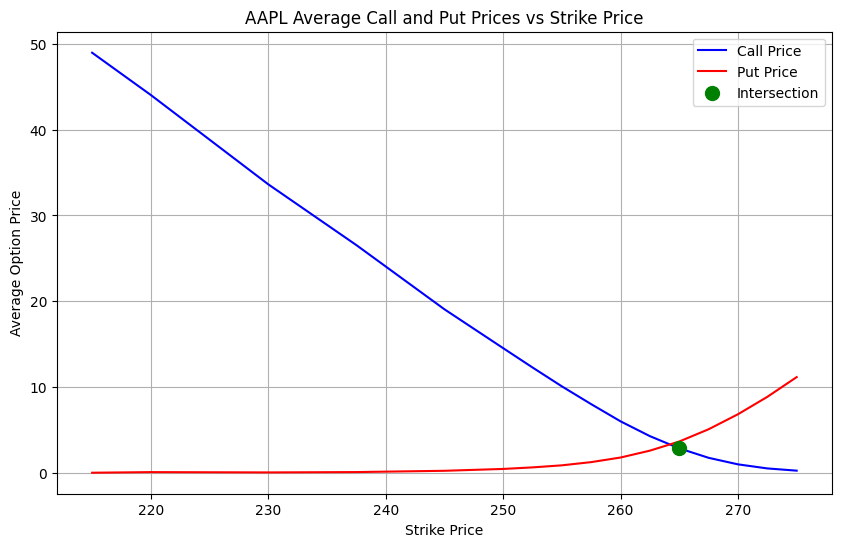

Approximate strike price at intersection: 265.0


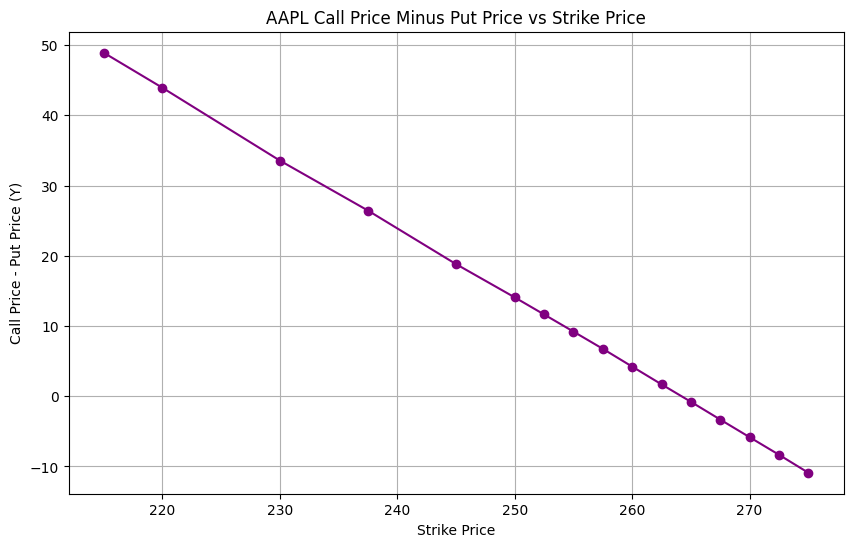


Sample data:
   strike  Avg_Call_Price  Avg_Put_Price       Y
0   215.0          48.950          0.040  48.910
1   220.0          44.025          0.110  43.915
2   230.0          33.625          0.075  33.550
3   237.5          26.550          0.115  26.435
4   245.0          19.075          0.265  18.810
5   250.0          14.550          0.480  14.070
6   252.5          12.300          0.660  11.640
7   255.0          10.100          0.900   9.200
8   257.5           8.025          1.275   6.750
9   260.0           6.025          1.810   4.215


In [2]:
# European Options Analysis: Call and Put Prices vs Strike Price

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Step 1: Select Company
# -----------------------
ticker_symbol = "AAPL"  # You can change this to any company with active European options
ticker = yf.Ticker(ticker_symbol)

# Fetch available option expiration dates
exp_dates = ticker.options
print("Available option expirations:", exp_dates)

# Select an expiration 2-4 months ahead
expiry = exp_dates[1]

# Fetch option chain for selected expiration
opt_chain = ticker.option_chain(expiry)
calls = opt_chain.calls
puts = opt_chain.puts

# Current stock price (Adjusted Close)
stock_price = ticker.history(period="1d")['Close'].iloc[-1]
today = pd.Timestamp.today().normalize()
time_to_maturity = (pd.to_datetime(expiry) - today).days

# -----------------------
# Step 2: Compute Average Option Prices
# -----------------------
calls['Avg_Call_Price'] = (calls['bid'] + calls['ask']) / 2
puts['Avg_Put_Price'] = (puts['bid'] + puts['ask']) / 2

# Keep only relevant columns
calls = calls[['strike', 'Avg_Call_Price']]
puts = puts[['strike', 'Avg_Put_Price']]

# Merge by strike price
df = pd.merge(calls, puts, on='strike')

# -----------------------
# Part (a): Call and Put Prices vs Strike Price
# -----------------------
plt.figure(figsize=(10,6))
plt.plot(df['strike'], df['Avg_Call_Price'], color='blue', label='Call Price')
plt.plot(df['strike'], df['Avg_Put_Price'], color='red', label='Put Price')

# Find approximate intersection
df['diff'] = abs(df['Avg_Call_Price'] - df['Avg_Put_Price'])
intersection_idx = df['diff'].idxmin()
intersection_strike = df.loc[intersection_idx, 'strike']
intersection_price = df.loc[intersection_idx, 'Avg_Call_Price']

# Highlight intersection point
plt.scatter(intersection_strike, intersection_price, color='green', s=100, zorder=5, label='Intersection')

plt.xlabel('Strike Price')
plt.ylabel('Average Option Price')
plt.title(f'{ticker_symbol} Average Call and Put Prices vs Strike Price')
plt.legend()
plt.grid(True)
plt.show()

print(f"Approximate strike price at intersection: {intersection_strike}")

# -----------------------
# Part (b): Call Price minus Put Price (Y)
# -----------------------
df['Y'] = df['Avg_Call_Price'] - df['Avg_Put_Price']

plt.figure(figsize=(10,6))
plt.plot(df['strike'], df['Y'], color='purple', marker='o')
plt.xlabel('Strike Price')
plt.ylabel('Call Price - Put Price (Y)')
plt.title(f'{ticker_symbol} Call Price Minus Put Price vs Strike Price')
plt.grid(True)
plt.show()

# -----------------------
# Optional: Display sample data
# -----------------------
print("\nSample data:")
print(df[['strike', 'Avg_Call_Price', 'Avg_Put_Price', 'Y']].head(10))